In [31]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:

import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv('mnist_train.csv')
t = df.iloc[:, 0] # the labels column
x = df.iloc[:, 1:] # the pixels columns
x_train_val , x_test, y_train_val, y_test = train_test_split(x , t , test_size=0.20, random_state=42 , stratify=t)
# Adding stratify=y ensures the split isn't random in a way that accidentally leaves all the "9s" in the test set

x_train, x_val, y_train, y_val = train_test_split(x_train_val , y_train_val , test_size=0.25, random_state=42 , stratify=y_train_val)

#check the splitting done correctly
print(f"Training shapes: {x_train.shape , y_train.shape}")
print(f"Validation shapes: {x_val.shape , y_val.shape}")
print(f"Testing shapes: {x_test.shape , y_test.shape}")


x_train = x_train/255.0
x_val = x_val/255.0
x_test = x_test/255.0

# Convert to PyTorch tensors el pictures el kter htt2sm batches

train_features = torch.tensor(x_train.values , dtype=torch.float32)
train_labels = torch.tensor(y_train.values , dtype=torch.long)

train_dataset = TensorDataset(train_features, train_labels)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True  # Shuffle the training data 
                              )

val_features = torch.tensor(x_val.values , dtype=torch.float32)
val_labels = torch.tensor(y_val.values , dtype=torch.long)
val_dataset = TensorDataset(val_features, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=64)

test_features = torch.tensor(x_test.values , dtype=torch.float32)
test_labels = torch.tensor(y_test.values , dtype=torch.long)
test_dataset = TensorDataset(test_features, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=64)



Training shapes: ((36000, 784), (36000,))
Validation shapes: ((12000, 784), (12000,))
Testing shapes: ((12000, 784), (12000,))


In [33]:

class digit_recognition(nn.Module):
    def __init__(self):
        super().__init__()
        # 784 pixel input maps to 128 neuron  to 10 output (digits 0-9)
        # without sequential i have to define each layer separately and call each one to forward pass
        # 2 hidden layers
        self.model = nn.Sequential(
             nn.Linear(784 , 128 ), 
             nn.ReLU(), 
             nn.Linear(128 , 64),
             nn.ReLU(),
             nn.Linear(64 , 32 ),
             nn.ReLU(),
             nn.Linear(32 , 10)
             
         )
        self.loss_fn = nn.CrossEntropyLoss()
        #apply is built in method in torch that applies a function to every layer in the network
        self.apply(self._init_weights_)
         # Dropout layer with 20% dropout rate
    def _init_weights_(self , module):
        if isinstance(module , nn.Linear):
            nn.init.kaiming_normal_(module.weight , mode = 'fan_in' , nonlinearity='relu')
            if module.bias is not None:
             nn.init.zeros_(module.bias)
            
    def forward(self, x):
        return self.model(x)

    def training_step(self , train_dataloader, val_dataloader , epochs, lr = 0.01 ):
        #odel.parameters() contains:
        # Layer 1: Weights (784 x 128) and Biases (128)
        # Layer 2: Weights (128 x 64) and Biases (64)
        # Layer 3: Weights (64 x 32) and Biases (32)
        # Layer 4: Weights (32 x 10) and Biases (10)
    #optimizer = optim.SGD(model.parameters(), lr=0.01)
     
     #loss = nn.CrossEntropyLoss()
     optimizer = optim.SGD(self.parameters(), lr= lr)
     history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
     for epoch in range (epochs) :
         self.train()  # Set the model to training mode to enable droupout percentage
         #When a neural network trains, it tries to minimize loss on the training data.
         # If given enough capacity (layers, neurons), it can do this too well 
         # it starts memorizing specific training examples rather than learning general patterns.
         #Why Overfitting Happens: Co-adaptation
         #The deeper reason is something called co-adaptation. Neurons in a layer start to rely on each other in very specific ways.
         #Imagine neurons A, B, C working together:
         #Neuron A: detects a curve at top
         #Neuron B: detects a gap in middle  
         #Neuron C: always fires to "fix" A's mistakes

         #→ C never learns anything useful on its own
         #→ The trio only works as a unit
         #→ Remove any one of them → whole prediction collapses
         running_loss = 0.0 
         correct_predictions = 0
         total_predictions = 0
         
         for pixels , labels in train_dataloader :
                optimizer.zero_grad()  
                y_hat = self(pixels)  #foward pass
                current_loss = self.loss_fn(y_hat, labels) #compute  training loss
                # this loss is average loss across the batch size 
                current_loss.backward()    # Backpropagation to compute gradients
                optimizer.step()   # Update the weights (Gradient Descent)
                #if current_loss.item() < threshold:
                 #   print(f"Early stopping at epoch {epoch} with loss {current_loss.item()}")
                  #  return
                running_loss += current_loss.item() * labels.size(0)  # Accumulate total loss for whole batch
                #as batches size are not always equal so we need
                #to multiply the average loss by the batch size to get the total loss for that batch
        
              #If you are training a model to recognize digits (0-9), 
              # the output layer has 10 neurons. Each neuron represents one digit.
              # For a single image, the output (y_hat) is a vector of 10 numbers:
              # $$y_{hat} = [ -1.2,  0.5, 6.2, -0.3,  0.1,  0.8,  -2.1,  1.1, 0.0,  -0.5 ]
              # $$The first number (-1.2) corresponds to class 0.
              # The second number (0.5) corresponds to class 1.
              # The third number (6.2) corresponds to class 2 and so on 
              # so y hat will be 10 dimension as 10 neurons in o/p layer * number of images in batch
                predections = y_hat.argmax(dim=1)
                correct_predictions+= (predections==labels).sum().item()
                # assume corrct labels [ 2  3 ,6 ] for 3 images batch
                # and the predections are [ 2  1 ,6 ]
                # what.sum() do is to count how many times the predections are equal to the  labels
                #treating true = 1 [true , false , true ]=> 2  correct predictions
                total_predictions += labels.size(0)  # Total number of predictions made
                #as you may ask yourself why labels.size(0) arenot labels.size() 1 dimension
                #bec it returns object of type tensor and we need to specify the dimension to get integer
         train_loss  = running_loss / total_predictions
         train_accuracy = correct_predictions / total_predictions
         self.eval()
         val_loss_sum, val_correct, val_total = 0.0, 0, 0
 
         with torch.no_grad():                  
            for pixels, labels in val_dataloader:
                y_hat = self(pixels)
                loss  = self.loss_fn(y_hat, labels)
 
                val_loss_sum += loss.item() * labels.size(0)
                preds         = y_hat.argmax(dim=1)
                val_correct  += (preds == labels).sum().item()
                val_total    += labels.size(0)
 
         val_loss = val_loss_sum / val_total
         val_acc  = val_correct  / val_total
         history["train_loss"].append(train_loss)
         history["val_loss"].append(val_loss)
         history["train_acc"].append(train_accuracy)
         history["val_acc"].append(val_acc)
 
     print(f"Epoch {epoch:>2}/{epochs} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_accuracy:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")
  
     return history

Epoch 19/20 | Train Loss: 0.0951  Acc: 0.9730 | Val Loss: 0.1457  Acc: 0.9573


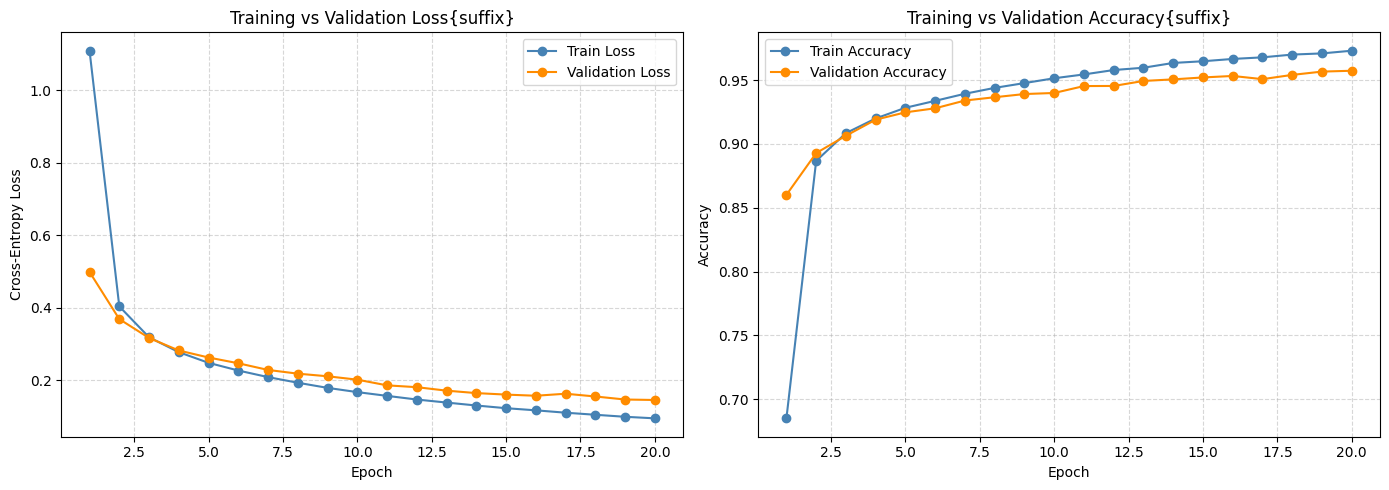

Plot saved → training_curves.png


In [34]:
def plot_history(history , title_suffix=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # — Loss plot —
    ax1.plot(epochs, history["train_loss"], label="Train Loss",      color="steelblue",  marker="o")
    ax1.plot(epochs, history["val_loss"],   label="Validation Loss", color="darkorange", marker="o")
    ax1.set_title("Training vs Validation Loss{suffix}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
 
    # — Accuracy plot —
    ax2.plot(epochs, history["train_acc"], label="Train Accuracy",      color="steelblue",  marker="o")
    ax2.plot(epochs, history["val_acc"],   label="Validation Accuracy", color="darkorange", marker="o")
    ax2.set_title("Training vs Validation Accuracy{suffix}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)
 
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Plot saved → training_curves.png")
 
 
# ─────────────────────────────────────────────
# 6. RUN EVERYTHING
# ─────────────────────────────────────────────
if __name__ == "__main__":
    model   = digit_recognition()
    history = model.training_step( train_dataloader, val_dataloader, epochs=20, lr=0.01)
    plot_history(history )


#Imagine you have 1,000 images and a Batch Size of 100.
#To complete 1 Epoch, the model needs to process 10 Batches.
#This means 1 Epoch = 10 Iterations.

# Analysis

In [35]:
# Model Evaluation
from sklearn.metrics import confusion_matrix, accuracy_score
# evaluates the trained model on unseen test data using: Accuracy & Confusion Matrix
def evaluate_on_test(model, test_loader): 
    y_true = [] # stores actual labels
    y_pred = [] # stores predicted labels
#Dropout is a technique where random neurons are temporarily deactivated during training to prevent overfitting and improve the model’s ability to generalize.
    model.eval() #Disables dropout and training-specific behavior -> عشان اطلع احسن توقع 
    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x)
            preds = outputs.argmax(dim=1) #argmax selects the class with highest score
            # Store results
            y_true.extend(y.numpy())
            y_pred.extend(preds.numpy())
    # Measures percentage of correct predictions (Accuracy)
    acc = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {acc:.4f}")
    # Shows classification errors between classes
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc

In [36]:
# Analyze how different learning rates affect training performance and convergence.
def experiment_learning_rates(lrs, epochs=10):
    results = {}

    for lr in lrs:
        print(f"\n-Training with LR = {lr}")
        # Initializing a new model ensures fair comparison by starting each experiment from scratch without influence from previous training.
        model = digit_recognition()
        # Train model
        history = model.training_step(train_dataloader, val_dataloader, epochs=epochs, lr=lr)
        plot_history(history)
        final_val_acc = history["val_acc"][-1]  # Store only the final val accuracy for the summary bar chart
        results[lr] = final_val_acc
     # ── Summary bar chart: final val accuracy across all learning rates ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(lr) for lr in lrs], [results[lr] for lr in lrs], color="steelblue")
    plt.title("Final Validation Accuracy vs Learning Rate")
    plt.xlabel("Learning Rate")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, lr in enumerate(lrs):
        plt.text(i, results[lr] + 0.01, f"{results[lr]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Learning Rate Analysis — Insights

- **High LR (0.1):** Converges fastest in the first few epochs but the loss curve tends to oscillate or even diverge because the weight updates overshoot the minimum.
- **Default LR (0.01):** Good balance — steady convergence, stable loss curve, strong final accuracy.
- **Low LR (0.001):** Converges smoothly but more slowly; may need more epochs to reach peak accuracy.
- **Very low LR (0.0001):** Barely moves in 10 epochs — the steps are too tiny. Loss stays high and accuracy lags far behind. This is classic underfitting due to insufficient learning.





-Training with LR = 0.1
Epoch  9/10 | Train Loss: 0.0235  Acc: 0.9932 | Val Loss: 0.1223  Acc: 0.9671


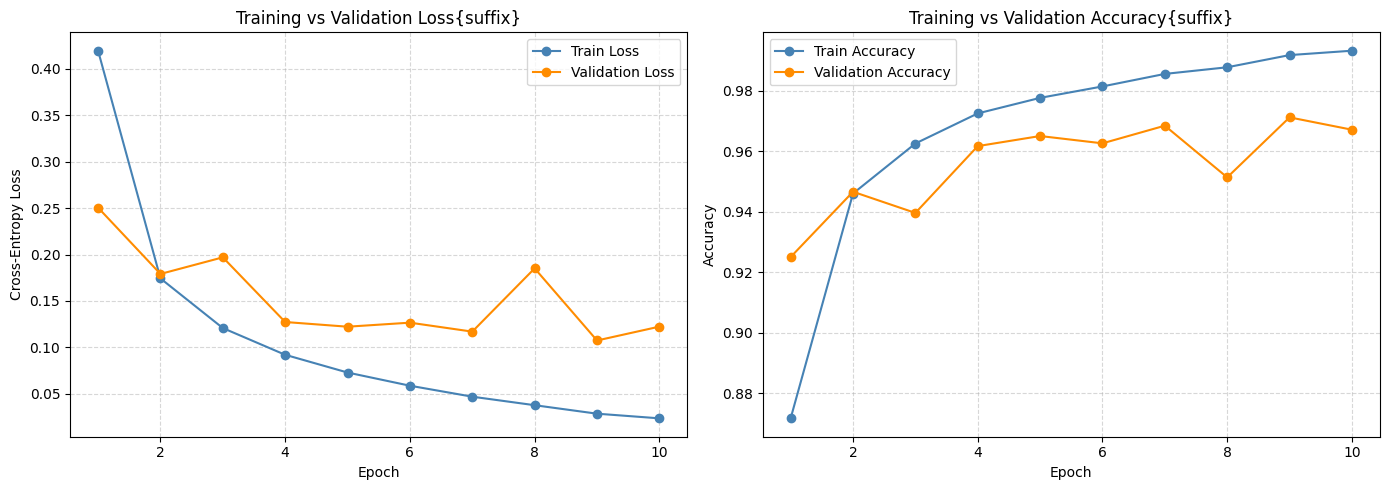

Plot saved → training_curves.png

-Training with LR = 0.01
Epoch  9/10 | Train Loss: 0.1558  Acc: 0.9546 | Val Loss: 0.1830  Acc: 0.9467


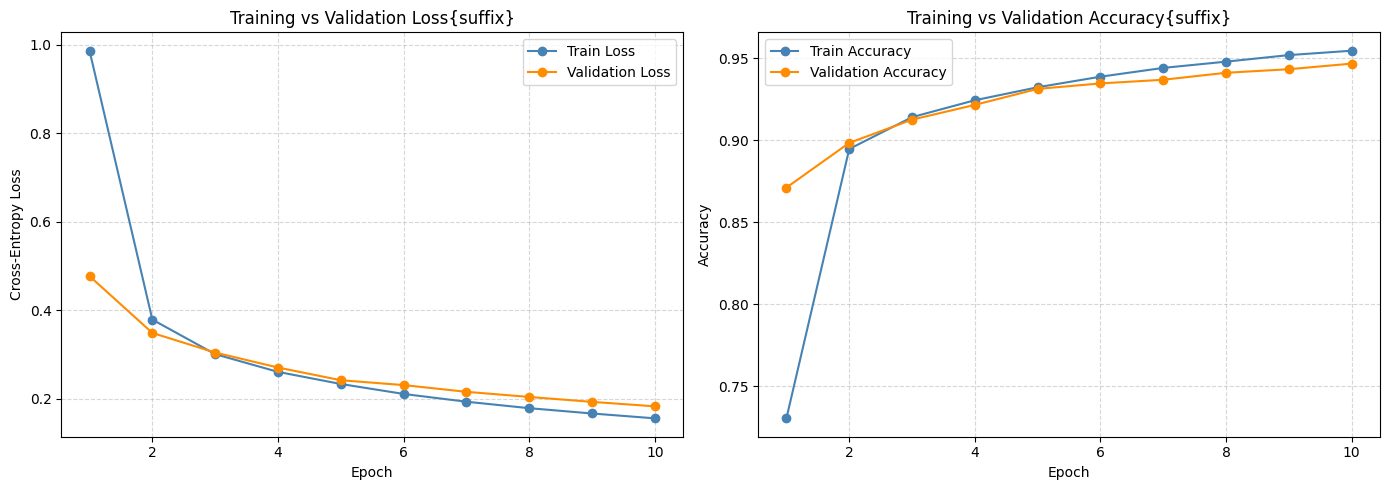

Plot saved → training_curves.png

-Training with LR = 0.001
Epoch  9/10 | Train Loss: 0.4551  Acc: 0.8742 | Val Loss: 0.4566  Acc: 0.8728


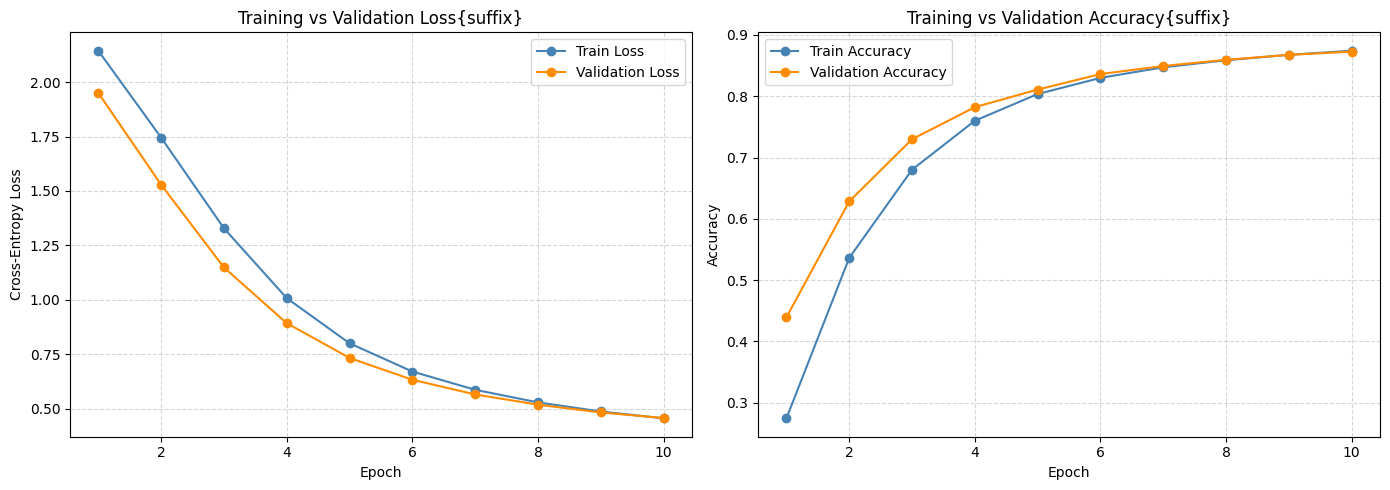

Plot saved → training_curves.png

-Training with LR = 0.0001
Epoch  9/10 | Train Loss: 1.9714  Acc: 0.3613 | Val Loss: 1.9503  Acc: 0.3785


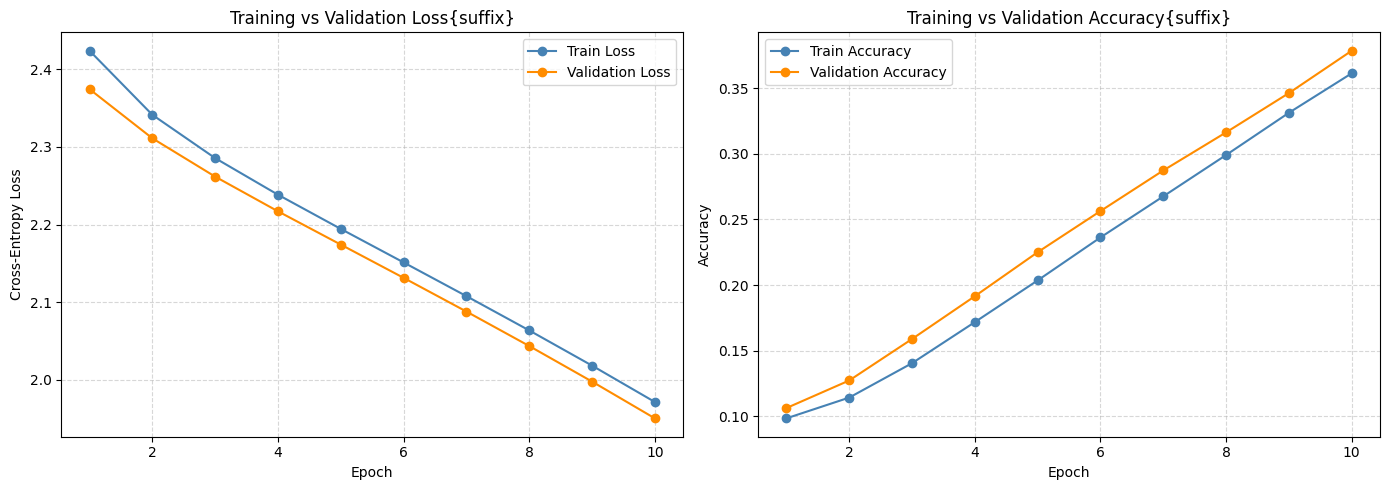

Plot saved → training_curves.png


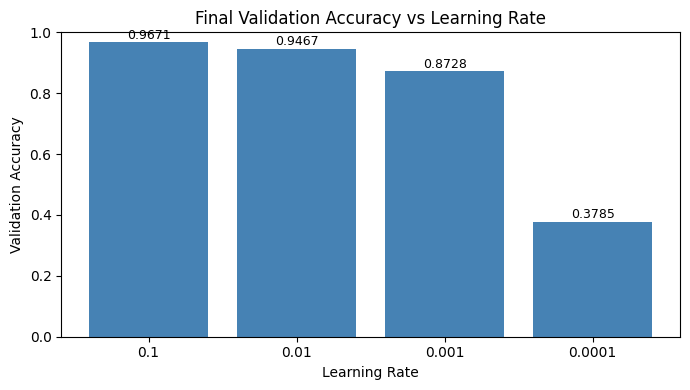

{0.1: 0.9670833333333333, 0.01: 0.94675, 0.001: 0.87275, 0.0001: 0.3785}


In [37]:
lr_results = experiment_learning_rates([0.1, 0.01, 0.001, 0.0001])
print(lr_results)

In [38]:
# Study how batch size affects training stability and generalization
def experiment_batch_sizes(batch_sizes, epochs=10):
    results = {}

    for bs in batch_sizes:
        print(f"\n-Training with Batch Size = {bs}")

        train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=bs)

        model = digit_recognition()
        history = model.training_step(train_loader, val_loader, epochs=epochs, lr=0.01)
        
        # Full training curves for this batch size
        plot_history(history, title_suffix=f"Batch={bs}")
        final_val_acc = history["val_acc"][-1]
        results[bs] = final_val_acc
     # ── Summary bar chart ──
    plt.figure(figsize=(7, 4))
    plt.bar([str(bs) for bs in batch_sizes], [results[bs] for bs in batch_sizes], color="darkorange")
    plt.title("Final Validation Accuracy vs Batch Size")
    plt.xlabel("Batch Size")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, bs in enumerate(batch_sizes):
        plt.text(i, results[bs] + 0.01, f"{results[bs]:.4f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
    return results

## Batch Size Analysis — Insights

- **Small batches (16, 32):** Each gradient update is computed from fewer samples, so the gradient estimate is noisier. This noise acts as implicit regularisation and often leads to better generalisation (higher val accuracy). However, training takes longer per epoch because there are more weight updates.
- **Medium batch (64):** Standard choice — good balance between speed and gradient quality.
- **Large batch (128):** Gradient estimates are very accurate (computed over many samples), so the loss curve is smooth. But the model tends to converge to "sharper" minima that generalise slightly worse. Each epoch is also faster because there are fewer updates.




-Training with Batch Size = 16
Epoch  9/10 | Train Loss: 0.0514  Acc: 0.9850 | Val Loss: 0.1139  Acc: 0.9674


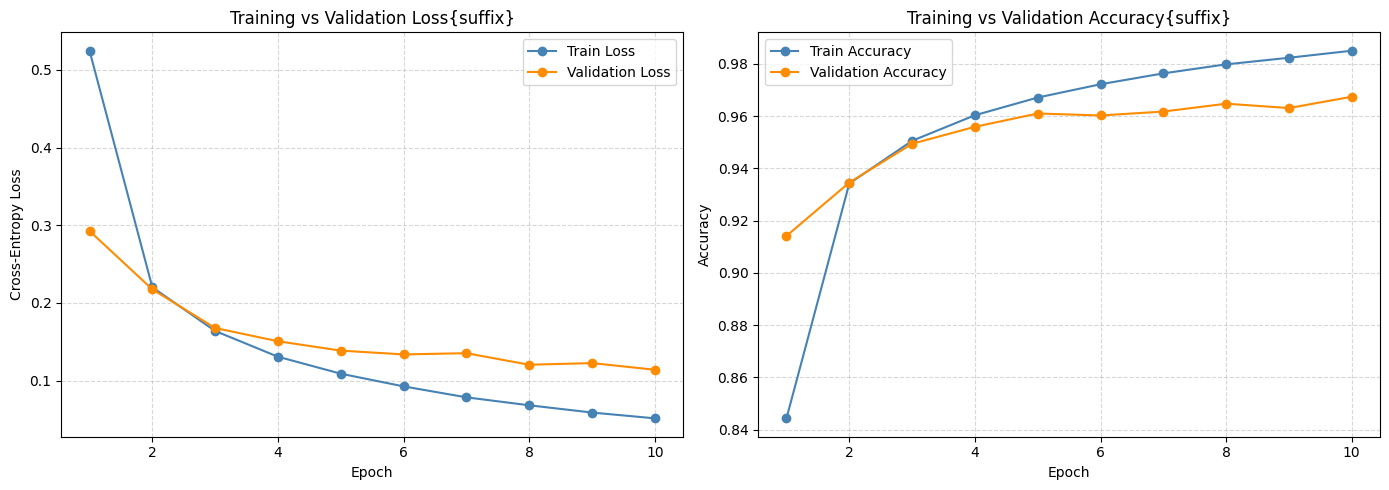

Plot saved → training_curves.png

-Training with Batch Size = 32
Epoch  9/10 | Train Loss: 0.1033  Acc: 0.9692 | Val Loss: 0.1430  Acc: 0.9594


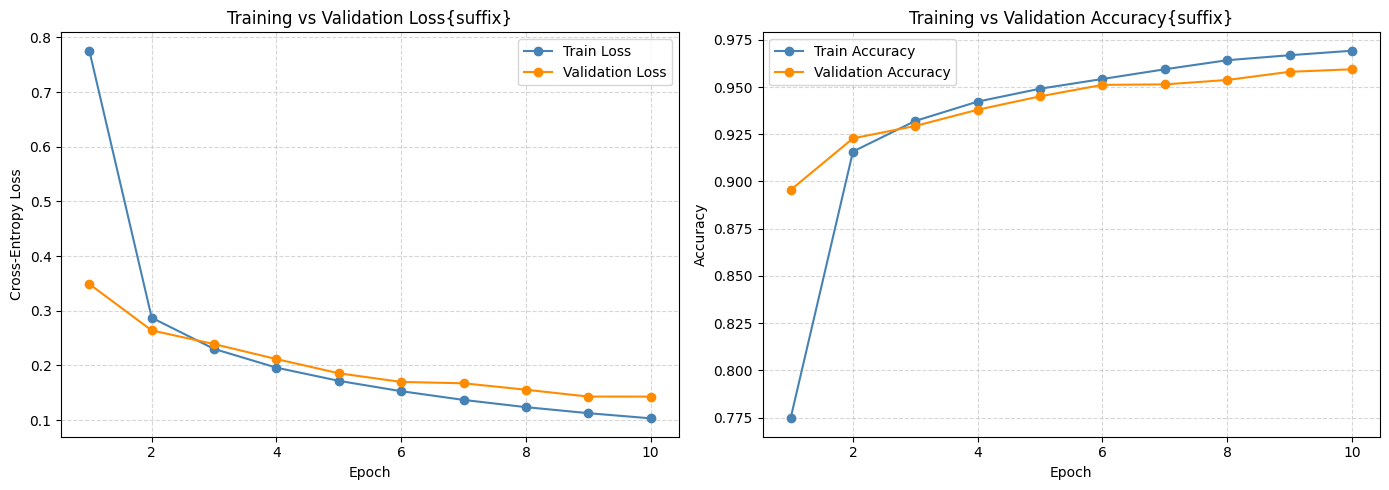

Plot saved → training_curves.png

-Training with Batch Size = 64
Epoch  9/10 | Train Loss: 0.1545  Acc: 0.9546 | Val Loss: 0.1833  Acc: 0.9473


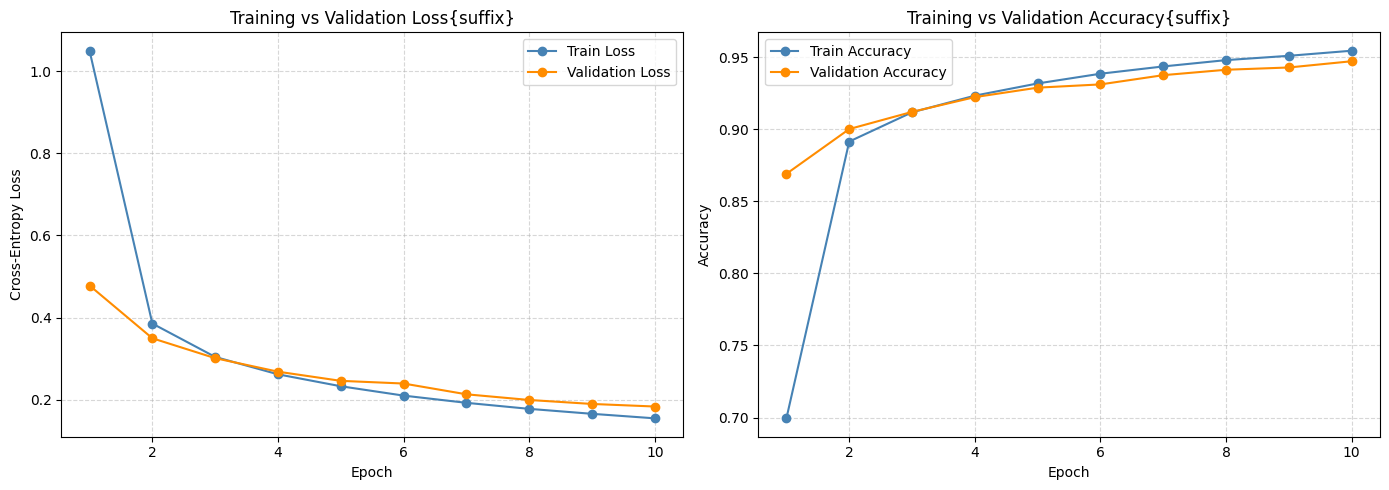

Plot saved → training_curves.png

-Training with Batch Size = 128
Epoch  9/10 | Train Loss: 0.2372  Acc: 0.9306 | Val Loss: 0.2655  Acc: 0.9237


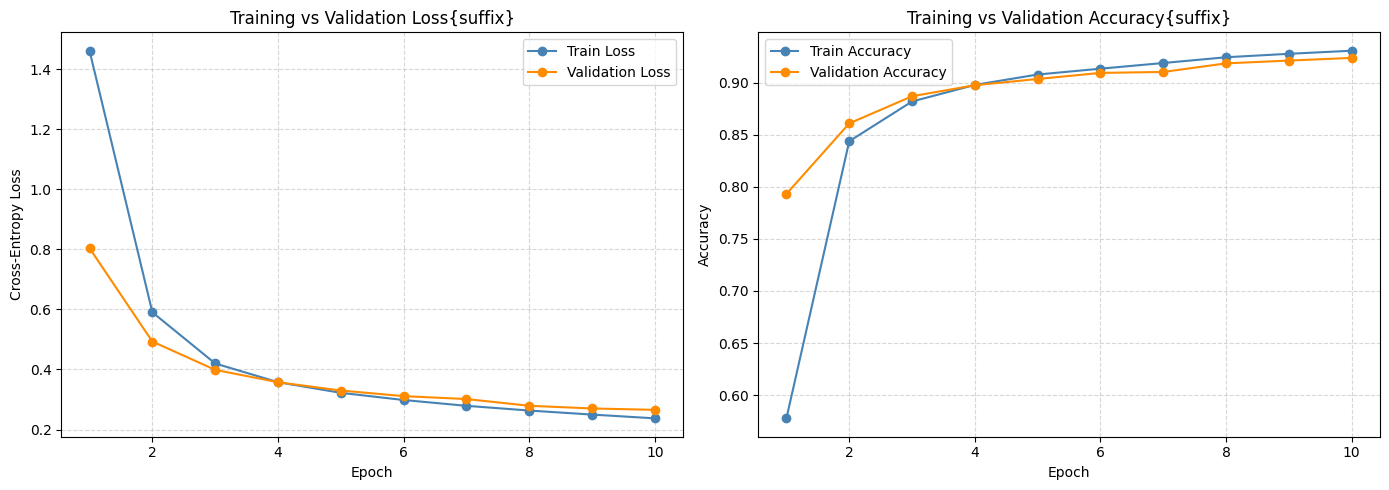

Plot saved → training_curves.png


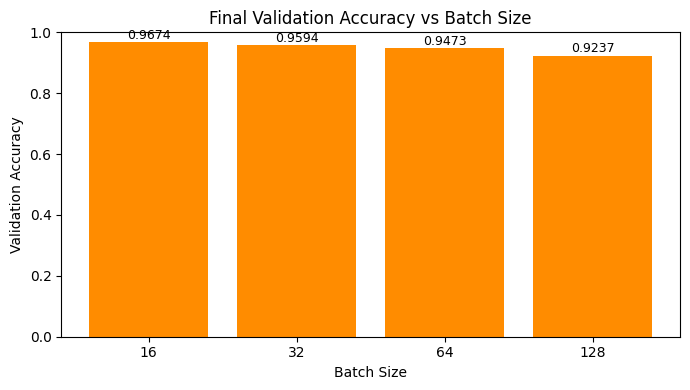

{16: 0.9674166666666667, 32: 0.9594166666666667, 64: 0.9473333333333334, 128: 0.92375}


In [39]:
bs_results = experiment_batch_sizes([16, 32, 64, 128])
print(bs_results)


--- Architecture: [64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.2928  Acc: 0.1301 | Val Loss: 2.2636  Acc: 0.2172
Epoch  1/10 | Train Loss: 2.1451  Acc: 0.3442 | Val Loss: 1.8927  Acc: 0.3434
Epoch  2/10 | Train Loss: 1.4336  Acc: 0.5503 | Val Loss: 0.9977  Acc: 0.6996
Epoch  3/10 | Train Loss: 0.7930  Acc: 0.7638 | Val Loss: 0.6714  Acc: 0.7974
Epoch  4/10 | Train Loss: 0.6232  Acc: 0.8159 | Val Loss: 0.5921  Acc: 0.8255
Epoch  5/10 | Train Loss: 0.5514  Acc: 0.8390 | Val Loss: 0.5381  Acc: 0.8460
Epoch  6/10 | Train Loss: 0.4934  Acc: 0.8588 | Val Loss: 0.4817  Acc: 0.8609
Epoch  7/10 | Train Loss: 0.4423  Acc: 0.8740 | Val Loss: 0.4344  Acc: 0.8768
Epoch  8/10 | Train Loss: 0.3982  Acc: 0.8868 | Val Loss: 0.4087  Acc: 0.8828
Epoch  9/10 | Train Loss: 0.3633  Acc: 0.8967 | Val Loss: 0.3708  Acc: 0.8919


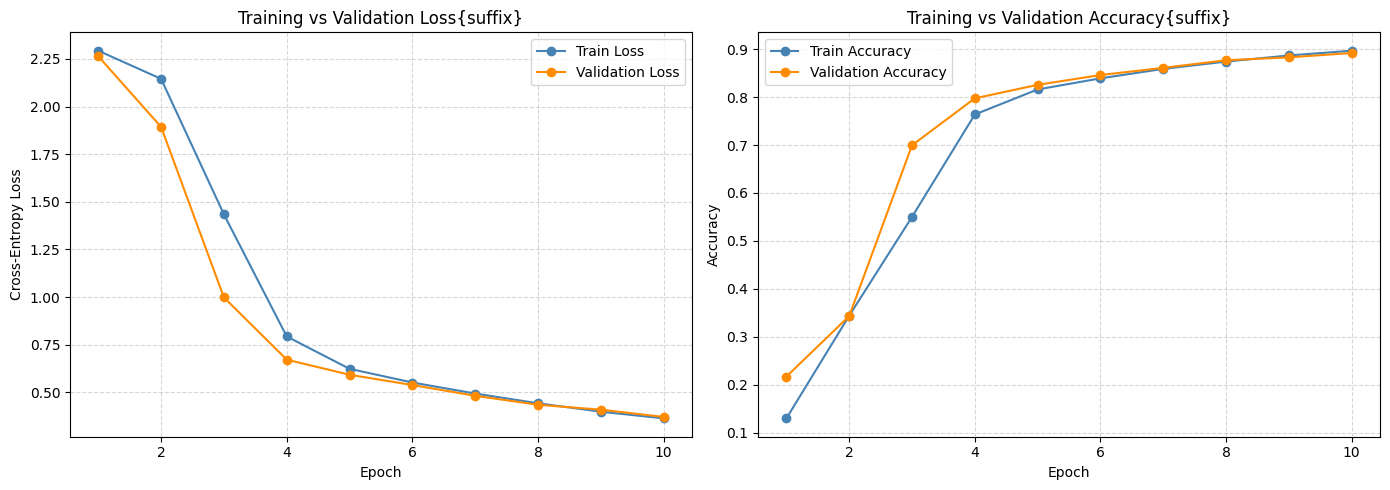

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2896  Acc: 0.1762 | Val Loss: 2.2619  Acc: 0.1895
Epoch  1/10 | Train Loss: 2.1368  Acc: 0.3464 | Val Loss: 1.8663  Acc: 0.4182
Epoch  2/10 | Train Loss: 1.3074  Acc: 0.6127 | Val Loss: 0.8984  Acc: 0.7267
Epoch  3/10 | Train Loss: 0.7118  Acc: 0.7847 | Val Loss: 0.6078  Acc: 0.8116
Epoch  4/10 | Train Loss: 0.5365  Acc: 0.8354 | Val Loss: 0.5033  Acc: 0.8491
Epoch  5/10 | Train Loss: 0.4540  Acc: 0.8639 | Val Loss: 0.4360  Acc: 0.8682
Epoch  6/10 | Train Loss: 0.4021  Acc: 0.8811 | Val Loss: 0.4009  Acc: 0.8805
Epoch  7/10 | Train Loss: 0.3653  Acc: 0.8923 | Val Loss: 0.3658  Acc: 0.8920
Epoch  8/10 | Train Loss: 0.3371  Acc: 0.9020 | Val Loss: 0.3540  Acc: 0.8968
Epoch  9/10 | Train Loss: 0.3146  Acc: 0.9089 | Val Loss: 0.3262  Acc: 0.9073


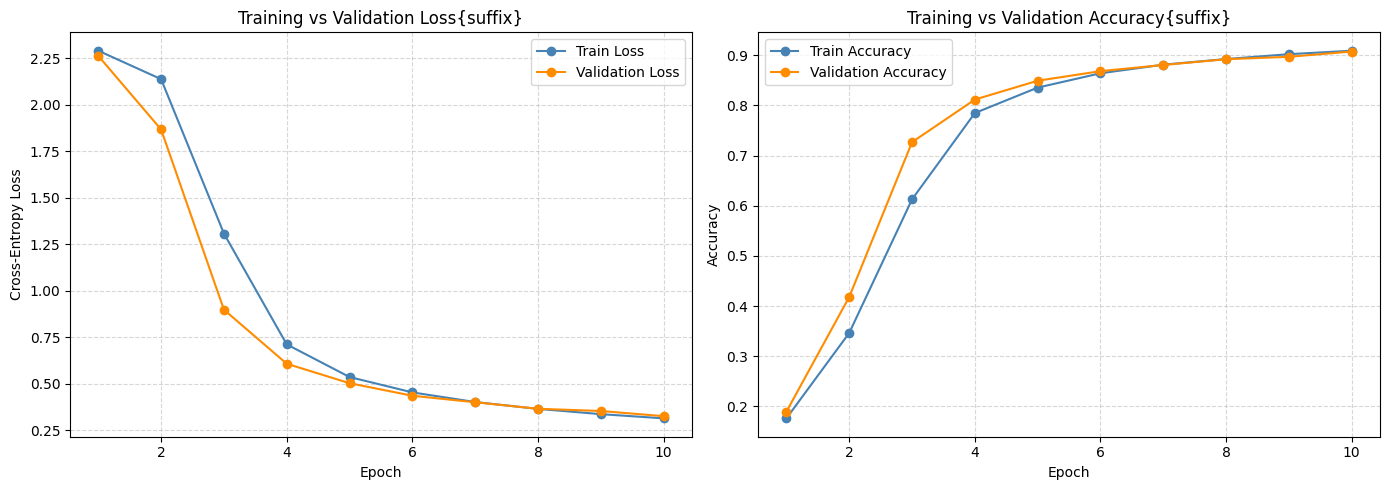

Plot saved → training_curves.png

--- Architecture: [256, 128, 64] ---
Epoch  0/10 | Train Loss: 2.2825  Acc: 0.2190 | Val Loss: 2.2388  Acc: 0.4329
Epoch  1/10 | Train Loss: 1.9451  Acc: 0.5361 | Val Loss: 1.3285  Acc: 0.6579
Epoch  2/10 | Train Loss: 0.8800  Acc: 0.7491 | Val Loss: 0.6605  Acc: 0.8000
Epoch  3/10 | Train Loss: 0.5601  Acc: 0.8339 | Val Loss: 0.5000  Acc: 0.8542
Epoch  4/10 | Train Loss: 0.4422  Acc: 0.8732 | Val Loss: 0.4228  Acc: 0.8741
Epoch  5/10 | Train Loss: 0.3843  Acc: 0.8897 | Val Loss: 0.3858  Acc: 0.8864
Epoch  6/10 | Train Loss: 0.3497  Acc: 0.9000 | Val Loss: 0.3698  Acc: 0.8898
Epoch  7/10 | Train Loss: 0.3253  Acc: 0.9059 | Val Loss: 0.3375  Acc: 0.9012
Epoch  8/10 | Train Loss: 0.3049  Acc: 0.9114 | Val Loss: 0.3158  Acc: 0.9084
Epoch  9/10 | Train Loss: 0.2870  Acc: 0.9171 | Val Loss: 0.2993  Acc: 0.9134


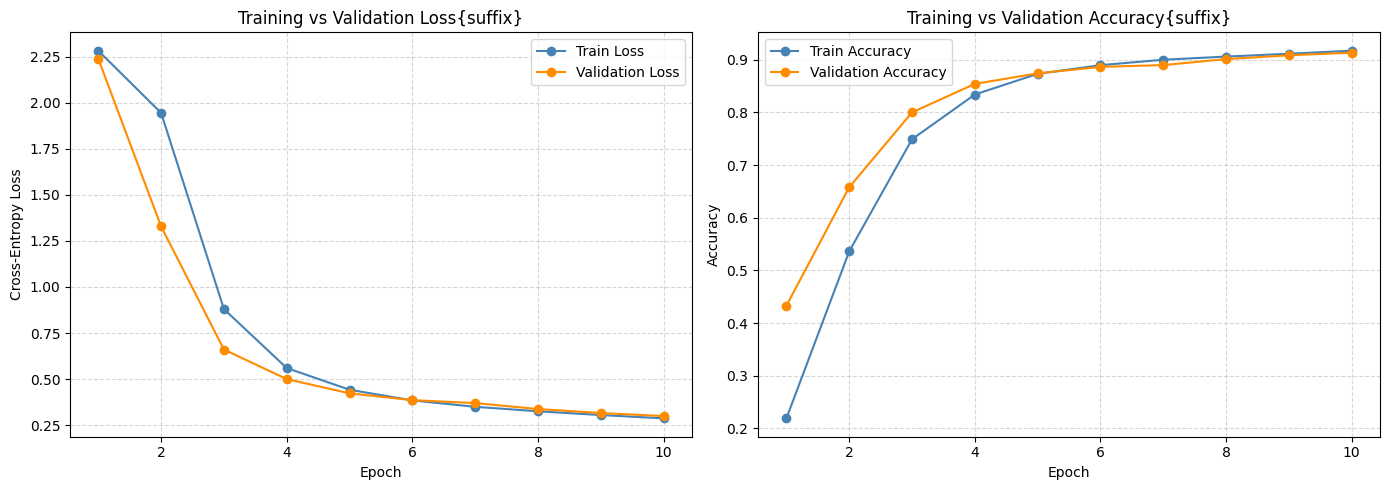

Plot saved → training_curves.png

--- Architecture: [512, 256, 128] ---
Epoch  0/10 | Train Loss: 2.2648  Acc: 0.3352 | Val Loss: 2.1896  Acc: 0.5893
Epoch  1/10 | Train Loss: 1.6919  Acc: 0.6527 | Val Loss: 0.9817  Acc: 0.7499
Epoch  2/10 | Train Loss: 0.7051  Acc: 0.8031 | Val Loss: 0.5588  Acc: 0.8300
Epoch  3/10 | Train Loss: 0.4760  Acc: 0.8637 | Val Loss: 0.4426  Acc: 0.8709
Epoch  4/10 | Train Loss: 0.3952  Acc: 0.8867 | Val Loss: 0.3942  Acc: 0.8846
Epoch  5/10 | Train Loss: 0.3545  Acc: 0.8984 | Val Loss: 0.3565  Acc: 0.8969
Epoch  6/10 | Train Loss: 0.3282  Acc: 0.9055 | Val Loss: 0.3325  Acc: 0.9045
Epoch  7/10 | Train Loss: 0.3070  Acc: 0.9102 | Val Loss: 0.3144  Acc: 0.9094
Epoch  8/10 | Train Loss: 0.2880  Acc: 0.9156 | Val Loss: 0.3076  Acc: 0.9119
Epoch  9/10 | Train Loss: 0.2708  Acc: 0.9215 | Val Loss: 0.2869  Acc: 0.9173


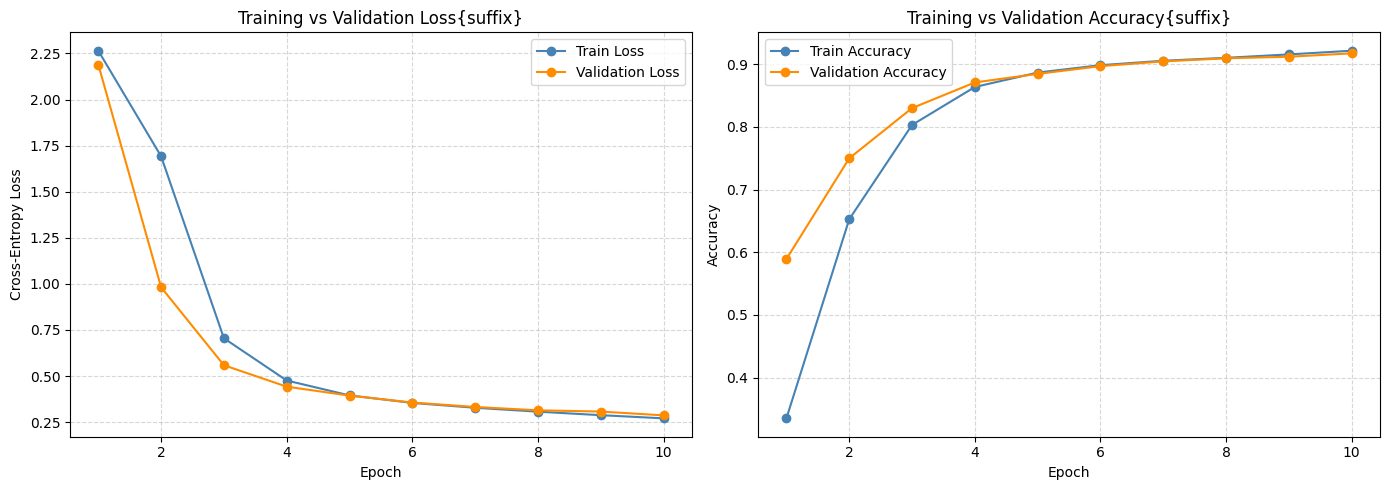

Plot saved → training_curves.png


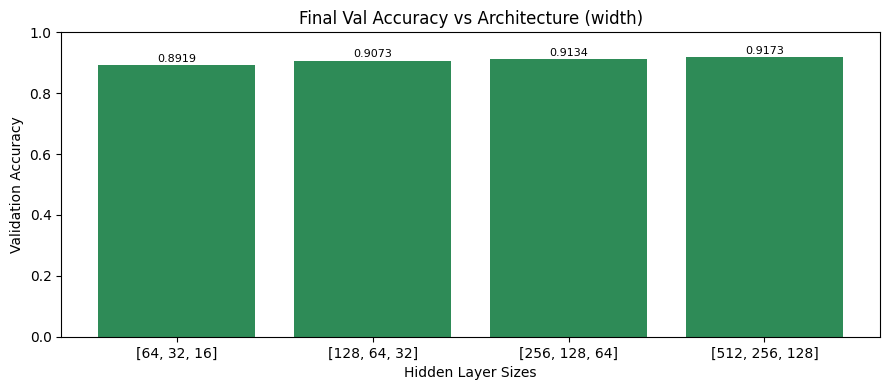

Width results: {'[64, 32, 16]': 0.8919166666666667, '[128, 64, 32]': 0.9073333333333333, '[256, 128, 64]': 0.9134166666666667, '[512, 256, 128]': 0.9173333333333333}

--- Architecture: [128] ---
Epoch  0/10 | Train Loss: 1.6044  Acc: 0.6905 | Val Loss: 0.9197  Acc: 0.8242
Epoch  1/10 | Train Loss: 0.6783  Acc: 0.8524 | Val Loss: 0.5502  Acc: 0.8668
Epoch  2/10 | Train Loss: 0.4818  Acc: 0.8790 | Val Loss: 0.4505  Acc: 0.8811
Epoch  3/10 | Train Loss: 0.4122  Acc: 0.8895 | Val Loss: 0.4050  Acc: 0.8876
Epoch  4/10 | Train Loss: 0.3760  Acc: 0.8964 | Val Loss: 0.3773  Acc: 0.8940
Epoch  5/10 | Train Loss: 0.3525  Acc: 0.9014 | Val Loss: 0.3591  Acc: 0.8992
Epoch  6/10 | Train Loss: 0.3355  Acc: 0.9056 | Val Loss: 0.3447  Acc: 0.9031
Epoch  7/10 | Train Loss: 0.3219  Acc: 0.9090 | Val Loss: 0.3334  Acc: 0.9055
Epoch  8/10 | Train Loss: 0.3106  Acc: 0.9116 | Val Loss: 0.3235  Acc: 0.9080
Epoch  9/10 | Train Loss: 0.3007  Acc: 0.9141 | Val Loss: 0.3157  Acc: 0.9093


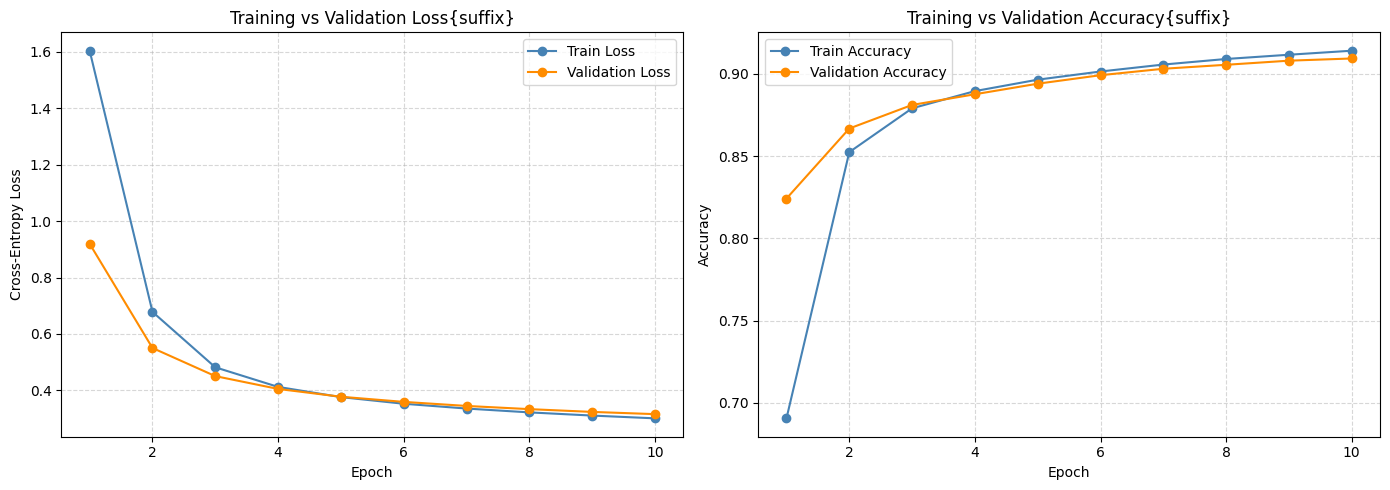

Plot saved → training_curves.png

--- Architecture: [128, 64] ---
Epoch  0/10 | Train Loss: 2.1681  Acc: 0.4047 | Val Loss: 1.8537  Acc: 0.5614
Epoch  1/10 | Train Loss: 1.2032  Acc: 0.7419 | Val Loss: 0.7286  Acc: 0.8125
Epoch  2/10 | Train Loss: 0.5812  Acc: 0.8439 | Val Loss: 0.5003  Acc: 0.8667
Epoch  3/10 | Train Loss: 0.4459  Acc: 0.8758 | Val Loss: 0.4260  Acc: 0.8799
Epoch  4/10 | Train Loss: 0.3890  Acc: 0.8907 | Val Loss: 0.3872  Acc: 0.8879
Epoch  5/10 | Train Loss: 0.3565  Acc: 0.8987 | Val Loss: 0.3628  Acc: 0.8964
Epoch  6/10 | Train Loss: 0.3335  Acc: 0.9048 | Val Loss: 0.3412  Acc: 0.9012
Epoch  7/10 | Train Loss: 0.3161  Acc: 0.9098 | Val Loss: 0.3265  Acc: 0.9080
Epoch  8/10 | Train Loss: 0.3010  Acc: 0.9137 | Val Loss: 0.3125  Acc: 0.9104
Epoch  9/10 | Train Loss: 0.2879  Acc: 0.9167 | Val Loss: 0.3009  Acc: 0.9158


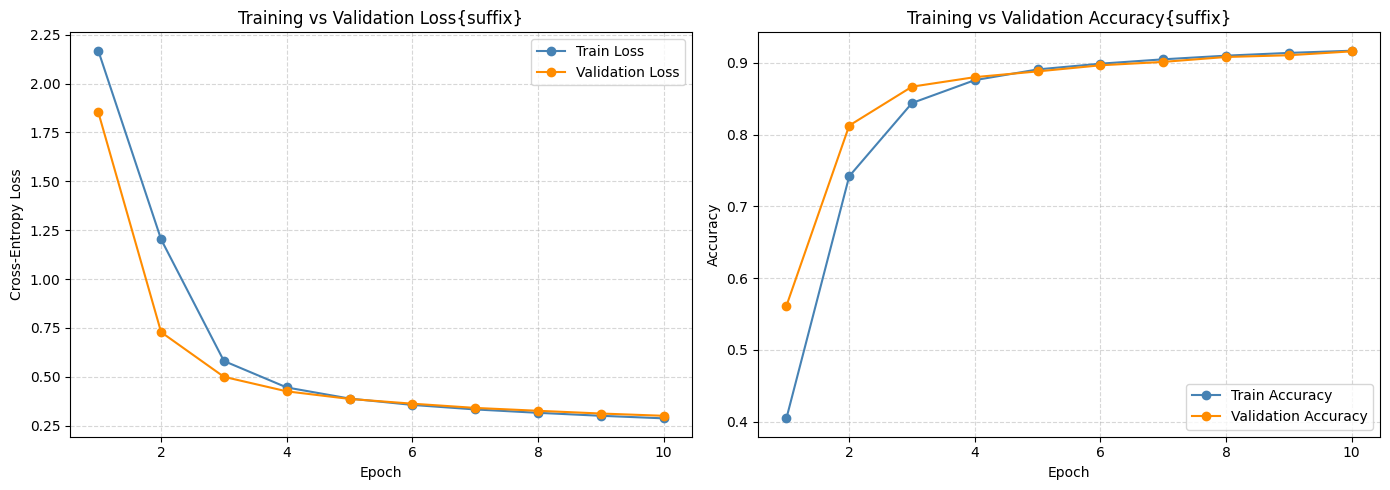

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2977  Acc: 0.1079 | Val Loss: 2.2829  Acc: 0.1476
Epoch  1/10 | Train Loss: 2.2268  Acc: 0.2939 | Val Loss: 2.0916  Acc: 0.3770
Epoch  2/10 | Train Loss: 1.6658  Acc: 0.5226 | Val Loss: 1.1448  Acc: 0.6896
Epoch  3/10 | Train Loss: 0.8054  Acc: 0.7730 | Val Loss: 0.6193  Acc: 0.8190
Epoch  4/10 | Train Loss: 0.5388  Acc: 0.8415 | Val Loss: 0.5044  Acc: 0.8525
Epoch  5/10 | Train Loss: 0.4520  Acc: 0.8690 | Val Loss: 0.4430  Acc: 0.8690
Epoch  6/10 | Train Loss: 0.3958  Acc: 0.8865 | Val Loss: 0.3915  Acc: 0.8892
Epoch  7/10 | Train Loss: 0.3538  Acc: 0.8991 | Val Loss: 0.3570  Acc: 0.8980
Epoch  8/10 | Train Loss: 0.3232  Acc: 0.9067 | Val Loss: 0.3330  Acc: 0.9057
Epoch  9/10 | Train Loss: 0.2987  Acc: 0.9143 | Val Loss: 0.3293  Acc: 0.9065


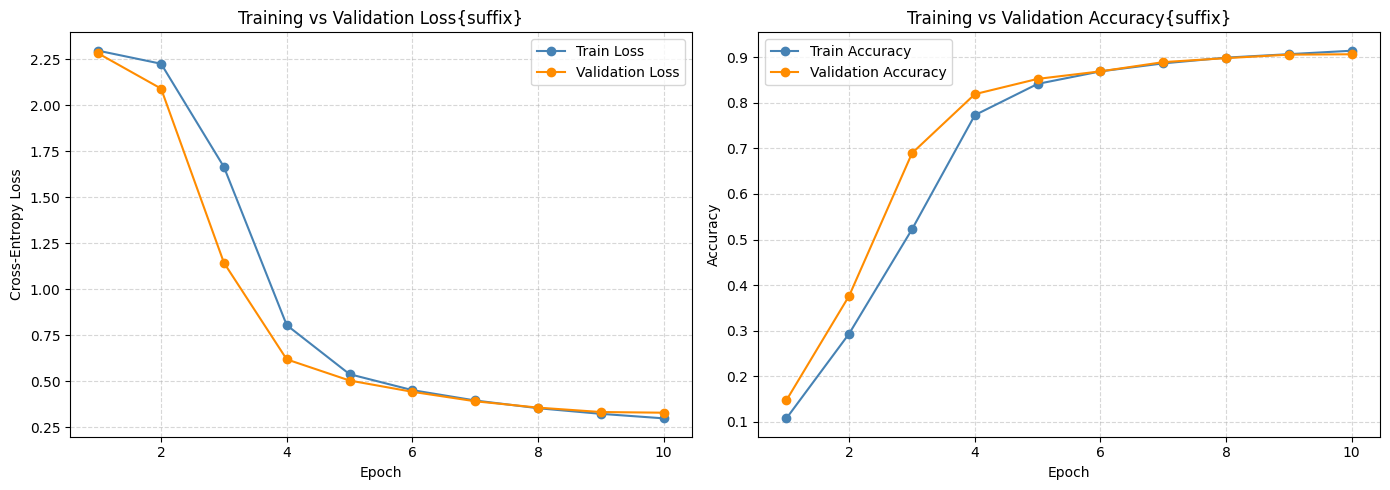

Plot saved → training_curves.png

--- Architecture: [128, 64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.3055  Acc: 0.1015 | Val Loss: 2.2951  Acc: 0.1296
Epoch  1/10 | Train Loss: 2.2786  Acc: 0.1903 | Val Loss: 2.2488  Acc: 0.3245
Epoch  2/10 | Train Loss: 2.1197  Acc: 0.2504 | Val Loss: 1.9307  Acc: 0.2220
Epoch  3/10 | Train Loss: 1.6532  Acc: 0.3995 | Val Loss: 1.3334  Acc: 0.6354
Epoch  4/10 | Train Loss: 0.9627  Acc: 0.7267 | Val Loss: 0.7388  Acc: 0.7858
Epoch  5/10 | Train Loss: 0.6497  Acc: 0.8077 | Val Loss: 0.6194  Acc: 0.8173
Epoch  6/10 | Train Loss: 0.5343  Acc: 0.8424 | Val Loss: 0.5036  Acc: 0.8526
Epoch  7/10 | Train Loss: 0.4471  Acc: 0.8710 | Val Loss: 0.4398  Acc: 0.8747
Epoch  8/10 | Train Loss: 0.3687  Acc: 0.8963 | Val Loss: 0.3495  Acc: 0.9002
Epoch  9/10 | Train Loss: 0.3073  Acc: 0.9126 | Val Loss: 0.3074  Acc: 0.9119


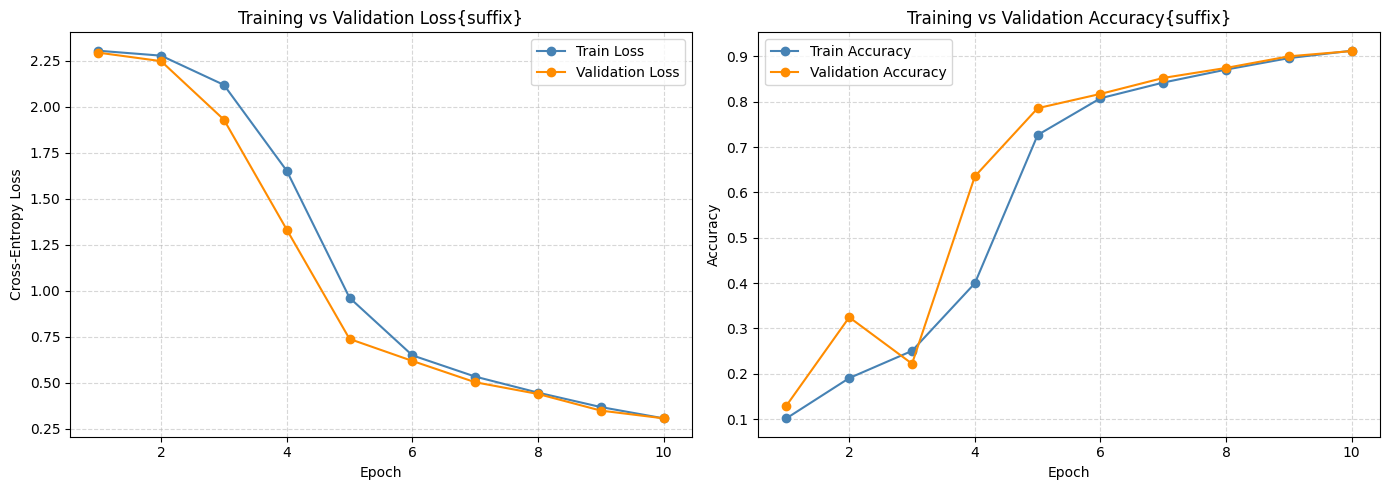

Plot saved → training_curves.png


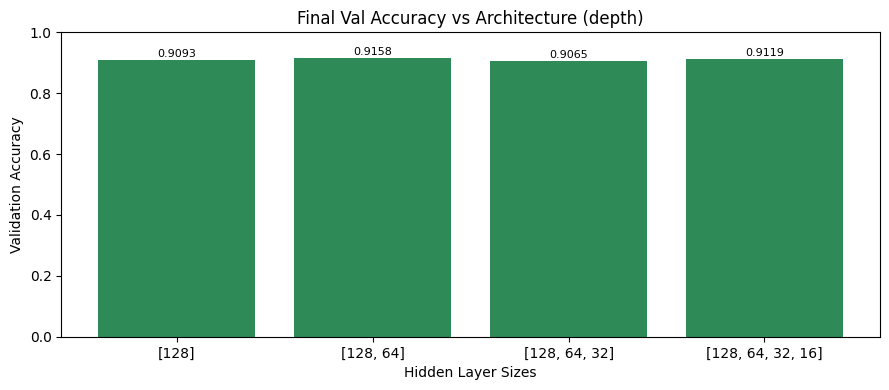

Depth results: {'[128]': 0.9093333333333333, '[128, 64]': 0.9158333333333334, '[128, 64, 32]': 0.9065, '[128, 64, 32, 16]': 0.9119166666666667}


In [41]:
# Evaluate the impact of changing both neuron count and number of layers.
#
# CustomNet now accepts a list of hidden sizes of any length, so we can test
# both different widths (neuron counts) and different depths (number of layers)
# in the same class without any changes.

class CustomNet(nn.Module):
    def __init__(self, hidden_sizes):
        """
        hidden_sizes : list of ints, e.g. [128, 64, 32]
                       → builds one hidden layer per element, then a 10-class output.
        """
        super().__init__()
        layers = []
        in_size = 784
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        layers.append(nn.Linear(in_size, 10))   # output layer
        self.model    = nn.Sequential(*layers)
        self.loss_fn  = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, train_loader, val_loader, epochs, lr=0.01):
        optimizer = optim.SGD(self.parameters(), lr=lr)
        # ← now tracks ALL 4 metrics so plot_history() works correctly
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        for epoch in range(epochs):
            # ── Training phase ──
            self.train()
            running_loss, correct, total = 0.0, 0, 0
            for x, y in train_loader:
                optimizer.zero_grad()
                out  = self(x)
                loss = self.loss_fn(out, y)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * y.size(0)
                correct      += (out.argmax(dim=1) == y).sum().item()
                total        += y.size(0)
            train_loss = running_loss / total
            train_acc  = correct / total

            # ── Validation phase ──
            self.eval()
            val_loss_sum, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for x, y in val_loader:
                    out  = self(x)
                    loss = self.loss_fn(out, y)
                    val_loss_sum += loss.item() * y.size(0)
                    val_correct  += (out.argmax(dim=1) == y).sum().item()
                    val_total    += y.size(0)
            val_loss = val_loss_sum / val_total
            val_acc  = val_correct  / val_total

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            print(f"Epoch {epoch:>2}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        return history


# ── Experiment A: vary neuron WIDTH (keep depth fixed at 3 hidden layers) ──
def experiment_neurons(configs, label="neurons"):
    results = {}
    for sizes in configs:
        label_str = str(sizes)
        print(f"\n--- Architecture: {label_str} ---")
        model = CustomNet(list(sizes))
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)
        plot_history(history, title_suffix=f"Arch {label_str}")
        results[str(sizes)] = history["val_acc"][-1]

    # Summary bar chart
    plt.figure(figsize=(9, 4))
    plt.bar(list(results.keys()), list(results.values()), color="seagreen")
    plt.title(f"Final Val Accuracy vs Architecture ({label})")
    plt.xlabel("Hidden Layer Sizes")
    plt.ylabel("Validation Accuracy")
    plt.ylim(0, 1)
    for i, (k, v) in enumerate(results.items()):
        plt.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()
    return results


# ── Neuron width experiment (depth = 3 hidden layers, width changes) ──
width_configs = [
    [64,  32,  16],
    [128, 64,  32],
    [256, 128, 64],
    [512, 256, 128],
]
width_results = experiment_neurons(width_configs, label="width")
print("Width results:", width_results)


# ── Depth experiment (width ≈ fixed ~128, number of hidden layers changes) ──
depth_configs = [
    [128],                    # 1 hidden layer
    [128, 64],                # 2 hidden layers
    [128, 64, 32],            # 3 hidden layers
    [128, 64, 32, 16],        # 4 hidden layers
]
depth_results = experiment_neurons(depth_configs, label="depth")
print("Depth results:", depth_results)


## Architecture Analysis — Insights

### Neuron Width (fixed 3 layers, changing neuron count)
- **Narrow networks [64,32,16]:** Limited capacity → underfits slightly; the bottleneck at 16 neurons before the output forces too much compression.
- **Medium [128,64,32]:** Usually the sweet spot on MNIST — enough capacity without wasting computation.
- **Wide [256,128,64] and [512,256,128]:** Marginal or no improvement over medium on MNIST because the task is not complex enough to need that many parameters. Training may also be slightly slower.

### Network Depth (fixed width ≈128, changing number of layers)
- **1 hidden layer:** Can still reach decent accuracy on MNIST (it is a simple dataset), but it misses some feature hierarchies.
- **2–3 hidden layers:** Better feature abstraction; generally higher accuracy.
- **4 hidden layers:** On simple tasks like MNIST, very deep networks with SGD can sometimes train slower because gradients weaken as they travel back through many layers (vanishing gradient). ReLU helps, but it does not fully eliminate the issue.




Increasing neurons improves performance slightly

MNIST is simple → large networks not necessary


--- Architecture: [64, 32, 16] ---
Epoch  0/10 | Train Loss: 2.2946  Acc: 0.1756 | Val Loss: 2.2648  Acc: 0.2087
Epoch  1/10 | Train Loss: 2.1421  Acc: 0.3162 | Val Loss: 1.9023  Acc: 0.4303
Epoch  2/10 | Train Loss: 1.4962  Acc: 0.5016 | Val Loss: 1.1525  Acc: 0.5781
Epoch  3/10 | Train Loss: 0.9627  Acc: 0.6720 | Val Loss: 0.8173  Acc: 0.7332
Epoch  4/10 | Train Loss: 0.7192  Acc: 0.7734 | Val Loss: 0.6864  Acc: 0.7905
Epoch  5/10 | Train Loss: 0.6142  Acc: 0.8145 | Val Loss: 0.5911  Acc: 0.8290
Epoch  6/10 | Train Loss: 0.5362  Acc: 0.8438 | Val Loss: 0.5276  Acc: 0.8478
Epoch  7/10 | Train Loss: 0.4689  Acc: 0.8658 | Val Loss: 0.4615  Acc: 0.8663
Epoch  8/10 | Train Loss: 0.4221  Acc: 0.8807 | Val Loss: 0.4228  Acc: 0.8794
Epoch  9/10 | Train Loss: 0.3910  Acc: 0.8883 | Val Loss: 0.3966  Acc: 0.8883


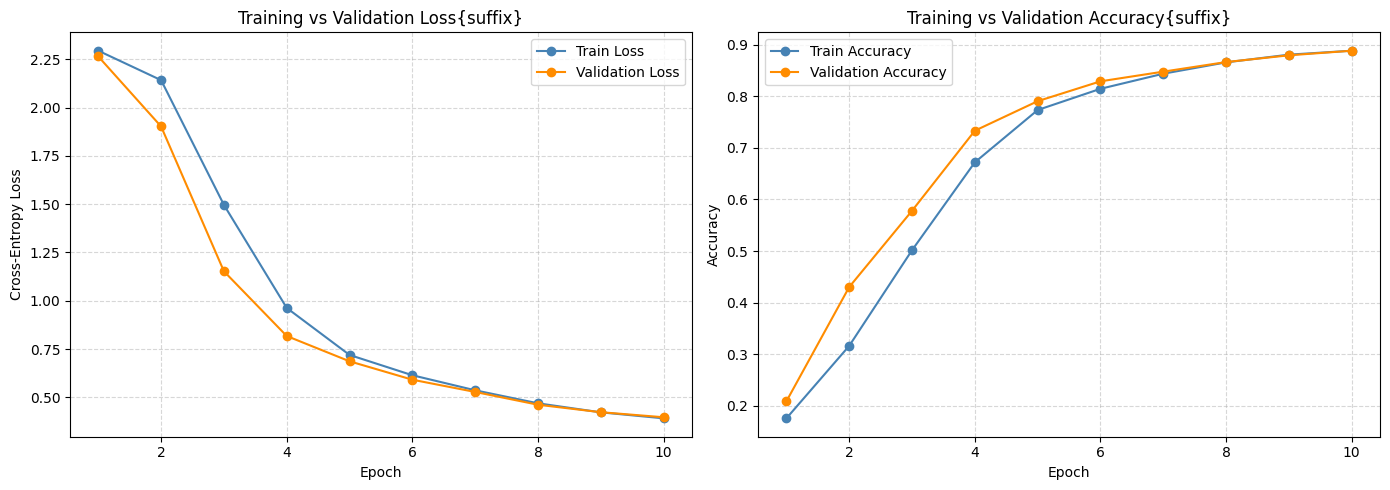

Plot saved → training_curves.png

--- Architecture: [128, 64, 32] ---
Epoch  0/10 | Train Loss: 2.2845  Acc: 0.1303 | Val Loss: 2.2508  Acc: 0.2511
Epoch  1/10 | Train Loss: 2.0536  Acc: 0.3955 | Val Loss: 1.6476  Acc: 0.4633
Epoch  2/10 | Train Loss: 1.2074  Acc: 0.6527 | Val Loss: 0.8525  Acc: 0.7584
Epoch  3/10 | Train Loss: 0.6520  Acc: 0.8128 | Val Loss: 0.5405  Acc: 0.8472
Epoch  4/10 | Train Loss: 0.4750  Acc: 0.8633 | Val Loss: 0.4486  Acc: 0.8697
Epoch  5/10 | Train Loss: 0.4099  Acc: 0.8829 | Val Loss: 0.4038  Acc: 0.8849
Epoch  6/10 | Train Loss: 0.3758  Acc: 0.8923 | Val Loss: 0.3859  Acc: 0.8906
Epoch  7/10 | Train Loss: 0.3510  Acc: 0.8994 | Val Loss: 0.3636  Acc: 0.8958
Epoch  8/10 | Train Loss: 0.3295  Acc: 0.9055 | Val Loss: 0.3484  Acc: 0.9002
Epoch  9/10 | Train Loss: 0.3110  Acc: 0.9102 | Val Loss: 0.3299  Acc: 0.9072


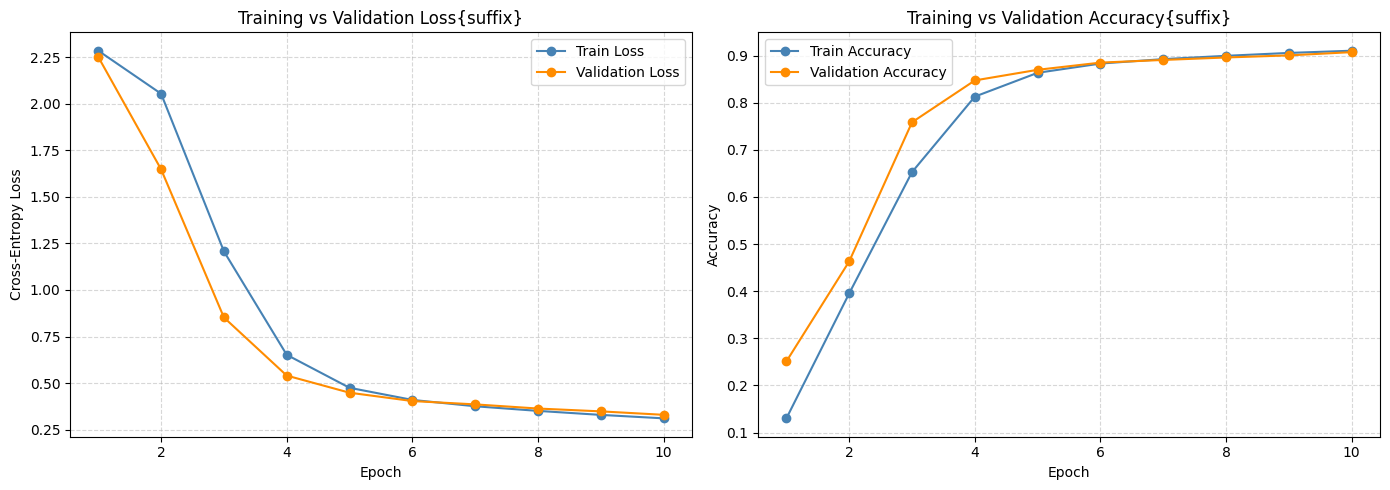

Plot saved → training_curves.png

--- Architecture: [256, 128, 64] ---
Epoch  0/10 | Train Loss: 2.2799  Acc: 0.2541 | Val Loss: 2.2375  Acc: 0.3975
Epoch  1/10 | Train Loss: 1.9790  Acc: 0.4803 | Val Loss: 1.5108  Acc: 0.5855
Epoch  2/10 | Train Loss: 1.0596  Acc: 0.6964 | Val Loss: 0.7806  Acc: 0.7538
Epoch  3/10 | Train Loss: 0.6453  Acc: 0.8068 | Val Loss: 0.5503  Acc: 0.8435
Epoch  4/10 | Train Loss: 0.4732  Acc: 0.8640 | Val Loss: 0.4574  Acc: 0.8645
Epoch  5/10 | Train Loss: 0.3982  Acc: 0.8874 | Val Loss: 0.3961  Acc: 0.8831
Epoch  6/10 | Train Loss: 0.3590  Acc: 0.8968 | Val Loss: 0.3623  Acc: 0.8959
Epoch  7/10 | Train Loss: 0.3314  Acc: 0.9051 | Val Loss: 0.3390  Acc: 0.9058
Epoch  8/10 | Train Loss: 0.3096  Acc: 0.9110 | Val Loss: 0.3412  Acc: 0.9012
Epoch  9/10 | Train Loss: 0.2902  Acc: 0.9163 | Val Loss: 0.3014  Acc: 0.9136


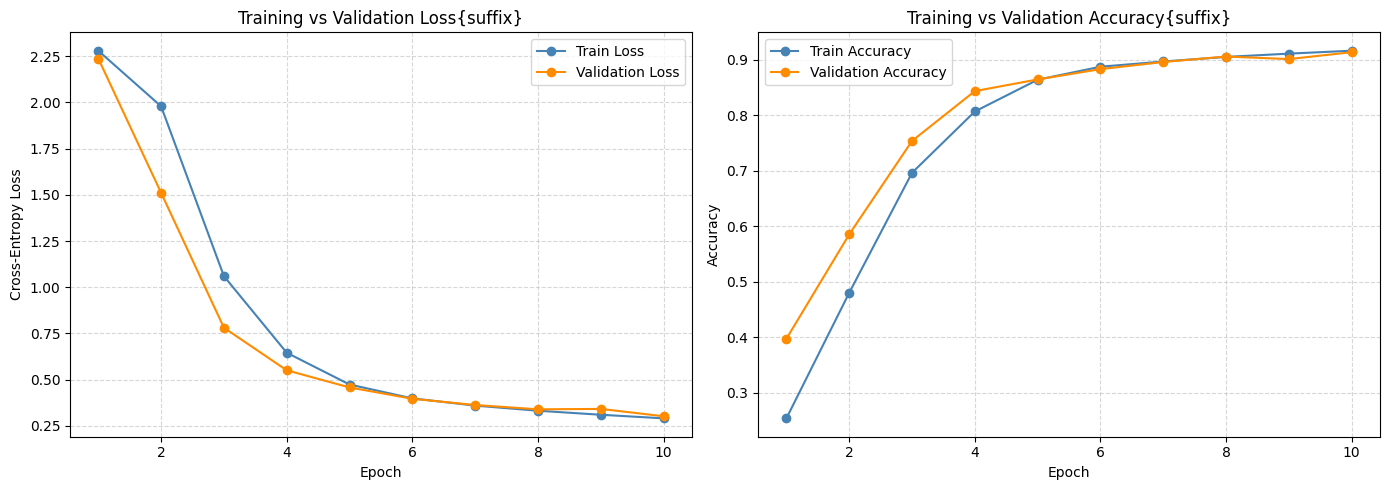

Plot saved → training_curves.png

--- Architecture: [512, 256, 128] ---
Epoch  0/10 | Train Loss: 2.2724  Acc: 0.3002 | Val Loss: 2.2139  Acc: 0.4957
Epoch  1/10 | Train Loss: 1.8548  Acc: 0.5666 | Val Loss: 1.1959  Acc: 0.7062
Epoch  2/10 | Train Loss: 0.7819  Acc: 0.7880 | Val Loss: 0.5819  Acc: 0.8313
Epoch  3/10 | Train Loss: 0.5049  Acc: 0.8536 | Val Loss: 0.4651  Acc: 0.8638
Epoch  4/10 | Train Loss: 0.4215  Acc: 0.8785 | Val Loss: 0.4127  Acc: 0.8780
Epoch  5/10 | Train Loss: 0.3745  Acc: 0.8933 | Val Loss: 0.3805  Acc: 0.8920
Epoch  6/10 | Train Loss: 0.3429  Acc: 0.9019 | Val Loss: 0.3510  Acc: 0.8992
Epoch  7/10 | Train Loss: 0.3184  Acc: 0.9082 | Val Loss: 0.3372  Acc: 0.9042
Epoch  8/10 | Train Loss: 0.2968  Acc: 0.9152 | Val Loss: 0.3072  Acc: 0.9142
Epoch  9/10 | Train Loss: 0.2775  Acc: 0.9203 | Val Loss: 0.2918  Acc: 0.9154


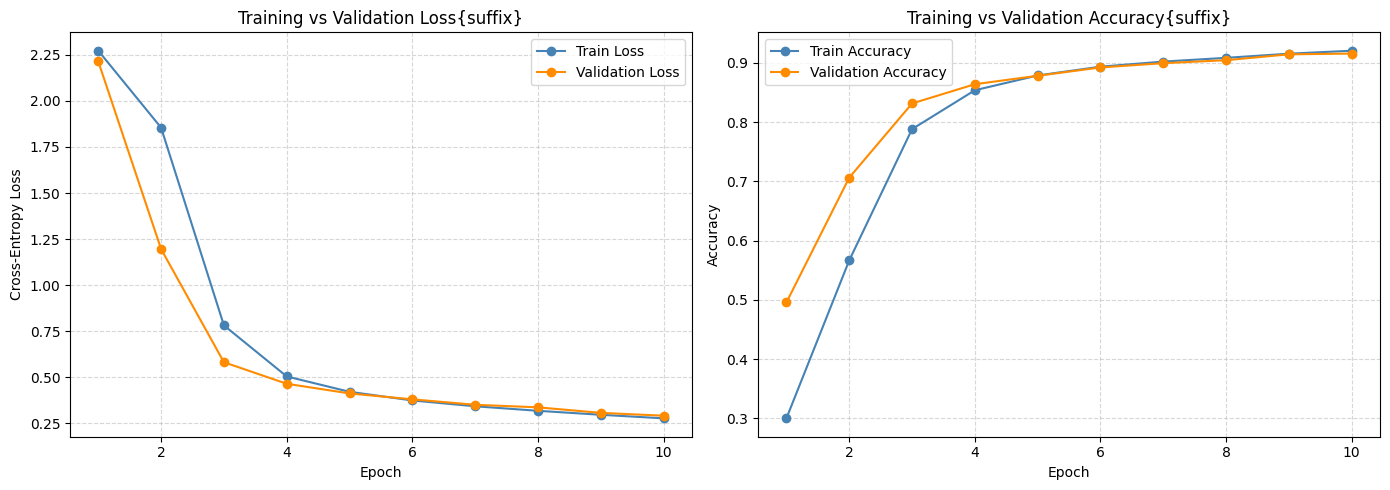

Plot saved → training_curves.png
{'[64, 32, 16]': 0.8883333333333333, '[128, 64, 32]': 0.9071666666666667, '[256, 128, 64]': 0.9135833333333333, '[512, 256, 128]': 0.9154166666666667}


In [43]:
def experiment_neurons(configs, label="neurons"):
    results = {}

    for sizes in configs:
        label_str = str(sizes)
        print(f"\n--- Architecture: {label_str} ---")

        model = CustomNet(sizes)
        history = model.training_step(train_dataloader, val_dataloader, epochs=10)
        plot_history(history, title_suffix=f"Arch {label_str}")

        results[label_str] = history["val_acc"][-1]

    return results

configs = [[64, 32, 16], [128, 64, 32], [256, 128, 64], [512, 256, 128]]
neuron_results = experiment_neurons(configs, label="width")

print(neuron_results)


## Best Model — Final Evaluation on Test Set

Epoch  0/10 | Train Loss: 1.3224  Acc: 0.5742 | Val Loss: 0.5915  Acc: 0.8412
Epoch  1/10 | Train Loss: 0.6402  Acc: 0.8045 | Val Loss: 0.4004  Acc: 0.8883
Epoch  2/10 | Train Loss: 0.4928  Acc: 0.8521 | Val Loss: 0.3336  Acc: 0.9056
Epoch  3/10 | Train Loss: 0.4202  Acc: 0.8734 | Val Loss: 0.2977  Acc: 0.9146
Epoch  4/10 | Train Loss: 0.3703  Acc: 0.8881 | Val Loss: 0.2701  Acc: 0.9204
Epoch  5/10 | Train Loss: 0.3366  Acc: 0.9007 | Val Loss: 0.2478  Acc: 0.9297
Epoch  6/10 | Train Loss: 0.3165  Acc: 0.9068 | Val Loss: 0.2301  Acc: 0.9339
Epoch  7/10 | Train Loss: 0.2897  Acc: 0.9131 | Val Loss: 0.2186  Acc: 0.9382
Epoch  8/10 | Train Loss: 0.2762  Acc: 0.9187 | Val Loss: 0.2089  Acc: 0.9390
Epoch  9/10 | Train Loss: 0.2560  Acc: 0.9244 | Val Loss: 0.1968  Acc: 0.9429


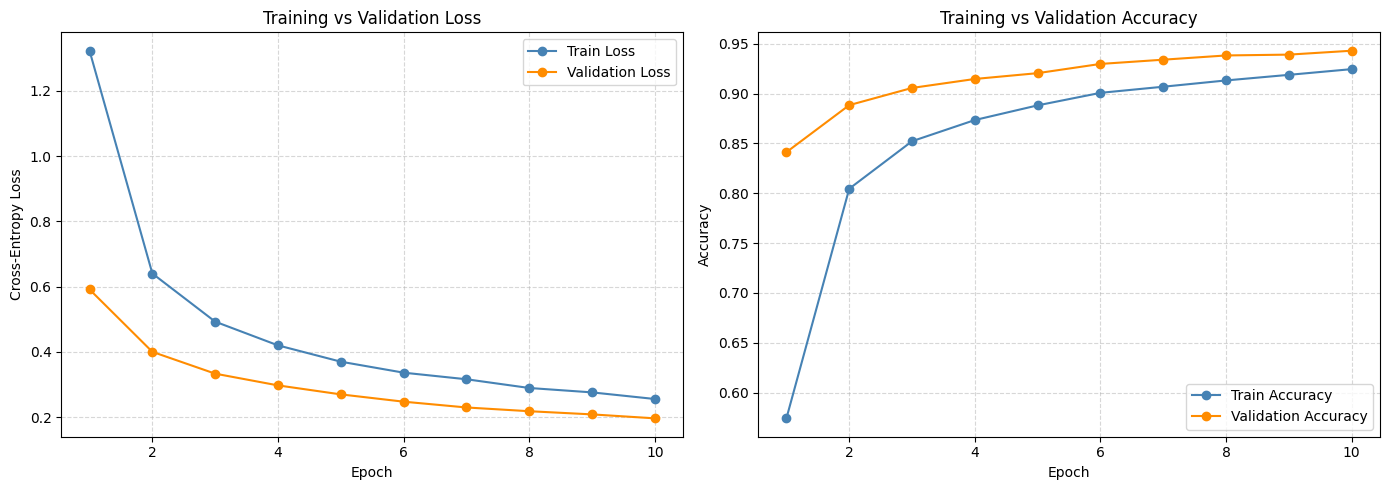

Plot saved → training_curves.png
Test Accuracy: 0.9447


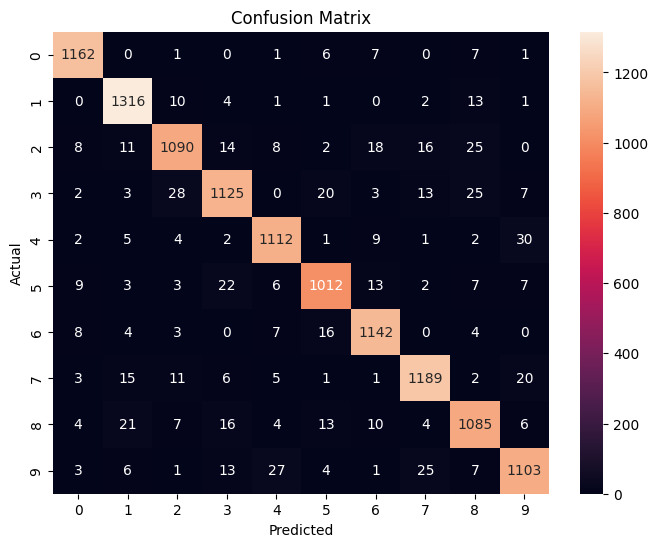

In [ ]:
# Train the best model configuration and evaluate it on test data.
best_model = digit_recognition()
history = best_model.training_step(train_dataloader, val_dataloader, epochs=10, lr=0.01)

plot_history(history)

test_acc = evaluate_on_test(best_model, test_dataloader)